<a href="https://colab.research.google.com/github/ChonlasakThamana/ChonlasakThamana/blob/main/PR_RandomForestClassifier_94_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ขั้นตอนที่ 1: 📗 importing the libraries

In [ ]:
!pip install textstat
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.2/239.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Text Processing Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud
from textstat import flesch_reading_ease, flesch_kincaid_grade

# Scikit-learn Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE, RFECV

# Non-linear Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("📚 All libraries imported successfully!")
print("🎯 Starting Enhanced Non-linear Text Classification Project")

📚 All libraries imported successfully!
🎯 Starting Enhanced Non-linear Text Classification Project


#ขั้นตอนที่ 2: 📄Import datasets

In [ ]:
import kagglehub

path = kagglehub.dataset_download("shawkyelgendy/fake-news-football")

print("Path to dataset files:", path)

100%|██████████| 2.19M/2.19M [00:00<00:00, 34.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shawkyelgendy/fake-news-football/versions/1


In [ ]:
fake=pd.read_csv("/root/.cache/kagglehub/datasets/shawkyelgendy/fake-news-football/versions/1/fake.csv")
real=pd.read_csv("/root/.cache/kagglehub/datasets/shawkyelgendy/fake-news-football/versions/1/real.csv")

In [ ]:
real.head()

,tweet
0,sun downs technical director: al-ahly respecte...
1,shawky gharib after the tie with enppi: our go...
2,"egyptian sports news today, wednesday 1/25/202..."
3,the main referees committee of the egyptian fo...
4,"haji bari, the striker of the future team, is ..."


In [ ]:
fake.head()

,tweet
0,"the tongue of his condition, now i saw things ..."
1,"by god the great, after i saw the derby of wyd..."
2,"believe in god, this zamalek fans are as good ..."
3,the coach appeared in the media and told the t...
4,asno smito\nwhoever knows her tells me a massa...


#ขั้นตอนที่ 3: 📄 Data Processing And Cleaning

In [ ]:
real["label"]=1
fake["label"]=0

In [ ]:
data = pd.concat([fake, real], axis=0)
data.columns = ["text", "label"]

In [ ]:
# ตรวจสอบค่าที่เป็น Missing
print("Missing values before dropping:")
print(data.isnull().sum())

# ลบแถวที่เป็น Missing
data.dropna(inplace=True)

# ตรวจสอบค่าที่เป็น Missing อีกครั้งหลังจากลบ
print("\nMissing values after dropping:")
print(data.isnull().sum())

Missing values before dropping:
text     17
label     0
dtype: int64

Missing values after dropping:
text     0
label    0
dtype: int64


In [ ]:
# ตรวจสอบค่าซ้ำกัน
print("Duplicate values before dropping:")
print(data.duplicated().sum())

# ลบค่าที่ซ้ำกัน
data.drop_duplicates(inplace=True)

# ตรวจสอบค่าซ้ำกันอีกครั้งหลักจากลบ
print("\nDuplicate values after dropping:")
print(data.duplicated().sum())

Duplicate values before dropping:
1027

Duplicate values after dropping:
0


In [ ]:
# ดาวน์โหลดทรัพยากรเพิ่มเติมสำหรับ Lemmatization
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to fix the LookupError

from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.corpus import wordnet

# ตั้งค่า Stemmer และ Lemmatizer
stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

# ฟังก์ชันช่วยในการทำ Lemmatization ให้ถูกต้องตาม Part of Speech
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess_text(text):
    """ฟังก์ชันสำหรับทำความสะอาดข้อความเบื้องต้น"""
    # 1. แปลงเป็นตัวพิมพ์เล็ก
    text = text.lower()
    # 2. ลบ URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 3. ลบ HTML tags
    text = re.sub(r'<.*?>', '', text)
    # 4. ลบคำที่มีตัวเลขปน
    text = re.sub(r'\w*\d\w*', '', text)
    # 5. ลบเครื่องหมายวรรคตอนและสัญลักษณ์พิเศษ (เก็บเฉพาะตัวอักษรและช่องว่าง)
    text = re.sub(r'[^a-z\s]', '', text)
    # 6. Tokenization (ตัดเป็นคำๆ)
    words = word_tokenize(text)
    # 7. ลบ Stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    # 8. รวมคำกลับเป็นประโยค และลบช่องว่างส่วนเกิน
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def stem_text(text):
    """ฟังก์ชันสำหรับทำ Stemming"""
    tokens = word_tokenize(text)
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return ' '.join(stemmed_tokens)

def lemmatize_text(text):
    """ฟังก์ชันสำหรับทำ Lemmatization"""
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token, get_wordnet_pos(token)) for token in tokens]
    return ' '.join(lemmatized_tokens)

# --- การนำไปใช้ ---
# 1. ทำความสะอาดข้อความเบื้องต้นก่อน
data['cleaned_text'] = data['text'].apply(preprocess_text)

# 2. แสดงผลลัพธ์ (ยังไม่ทำ Stemming หรือ Lemmatization)
print("ข้อมูลหลังทำความสะอาด:")
display(data.head())

ข้อมูลหลังทำความสะอาด:


,text,label,cleaned_text
0,"the tongue of his condition, now i saw things ...",0,tongue condition saw things confused shame you...
1,"by god the great, after i saw the derby of wyd...",0,god great saw derby wydad alraja almaghribi be...
2,"believe in god, this zamalek fans are as good ...",0,believe god zamalek fans good swear god celebr...
3,the coach appeared in the media and told the t...,0,coach appeared media told truth got told swear...
4,asno smito\nwhoever knows her tells me a massa...,0,asno smito whoever knows tells massage whoever...


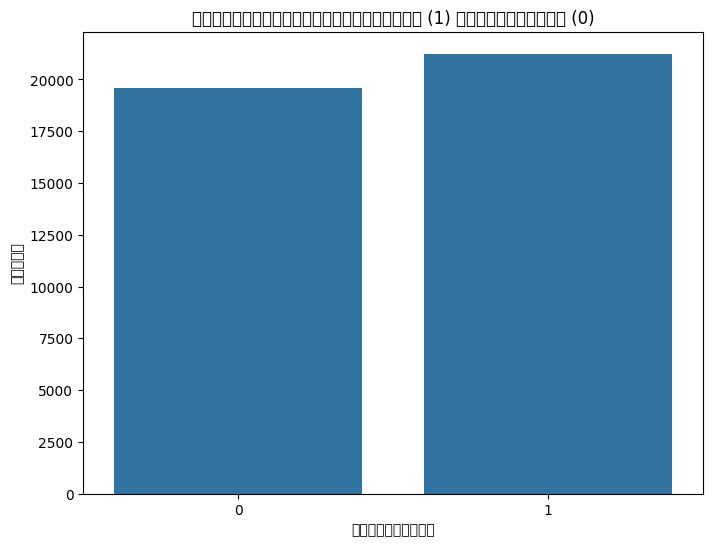

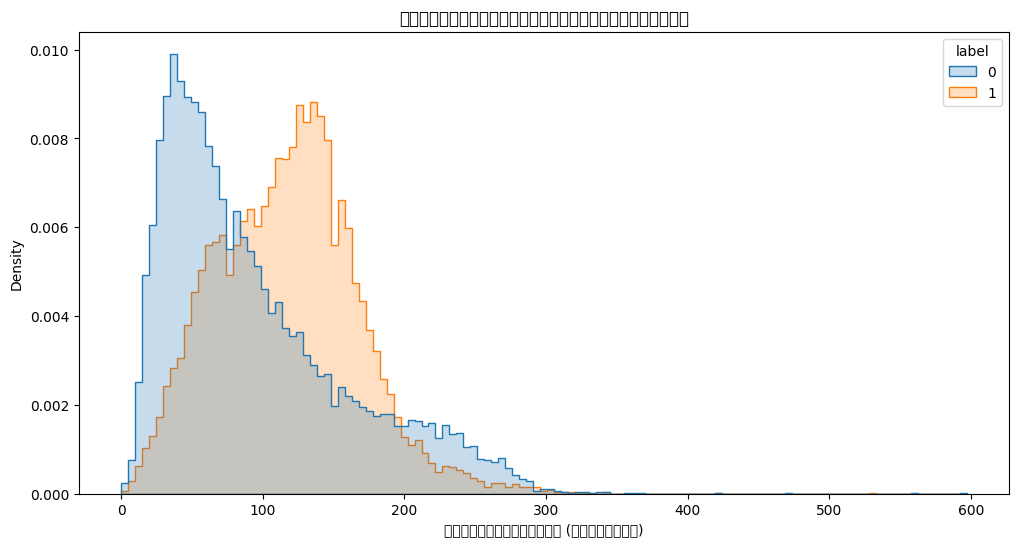

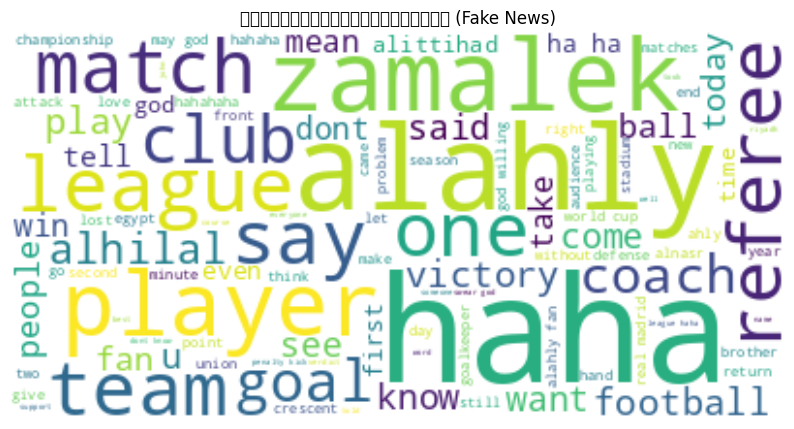

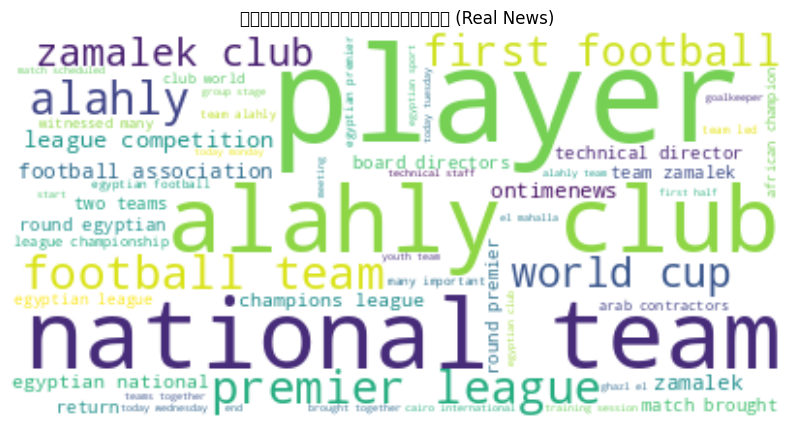

In [ ]:
# 1. การกระจายตัวของ Label
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=data)
plt.title('การกระจายตัวของข่าวจริง (1) และข่าวปลอม (0)')
plt.xlabel('ประเภทข่าว')
plt.ylabel('จำนวน')
plt.show()

# 2. วิเคราะห์ความยาวของข้อความ
data['text_length'] = data['cleaned_text'].apply(len)
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='text_length', hue='label', element='step', stat='density', common_norm=False)
plt.title('การกระจายตัวของความยาวข้อความ')
plt.xlabel('ความยาวข้อความ (ตัวอักษร)')
plt.show()

# 3. สร้าง Word Cloud
fake_text = " ".join(text for text in data[data['label'] == 0]['cleaned_text'])
real_text = " ".join(text for text in data[data['label'] == 1]['cleaned_text'])

# Word Cloud สำหรับข่าวปลอม
wordcloud_fake = WordCloud(max_words=100, background_color="white").generate(fake_text)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis("off")
plt.title("คำที่พบบ่อยในข่าวปลอม (Fake News)")
plt.show()

# Word Cloud สำหรับข่าวจริง
wordcloud_real = WordCloud(max_words=100, background_color="white").generate(real_text)
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis("off")
plt.title("คำที่พบบ่อยในข่าวจริง (Real News)")
plt.show()

#ขั้นตอนที่ 4: 📄 แบ่ง Test Set Train Set

In [ ]:
from sklearn.model_selection import train_test_split

X = data['cleaned_text']
y = data['label']

# แบ่งข้อมูลเป็น Train 80% และ Test 20%
# ใช้ stratify=y เพื่อให้สัดส่วนของ label ใน train และ test set เท่ากับข้อมูลทั้งหมด
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"จำนวนข้อมูลสำหรับ Train: {len(X_train)}")
print(f"จำนวนข้อมูลสำหรับ Test: {len(X_test)}")

จำนวนข้อมูลสำหรับ Train: 28576
จำนวนข้อมูลสำหรับ Test: 12248


#ขั้นตอนที่ 5: 📄 Feature Extraction (Text Vectorization)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# สร้างและ fit TfidfVectorizer กับข้อมูล Train เท่านั้น
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # จำกัดจำนวน feature เพื่อความรวดเร็ว
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

#ขั้นตอนที่ 6: 📄 Model Training & Evaluation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# สร้างและฝึกโมเดล RandomForest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_tfidf, y_train)

# ทำนายผลบน Test set
y_pred = rf_classifier.predict(X_test_tfidf)

# ประเมินผล
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9375

Confusion Matrix:
[[5445  429]
 [ 337 6037]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      5874
           1       0.93      0.95      0.94      6374

    accuracy                           0.94     12248
   macro avg       0.94      0.94      0.94     12248
weighted avg       0.94      0.94      0.94     12248



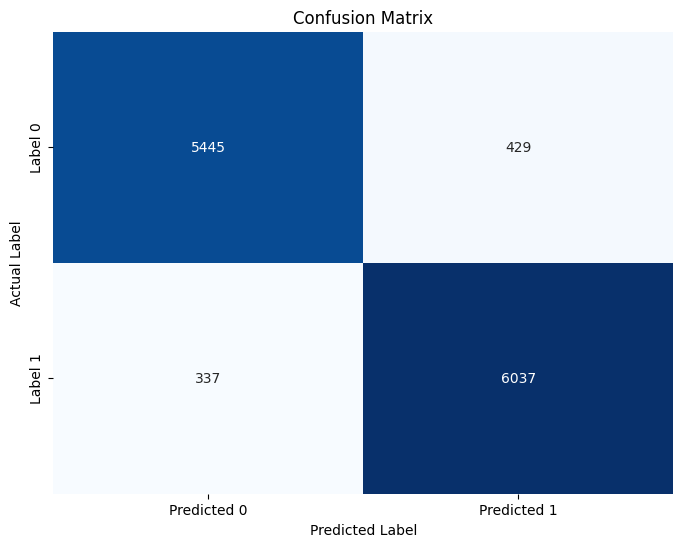

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Label 0', 'Label 1'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

#ขั้นตอนที่ 6: 📄 ทดสอบ

In [ ]:
# ขั้นตอนที่ 7: 🧪 ทดสอบโมเดลกับข้อมูลจริง (New Data)

# 1. กำหนดข้อความข่าวใหม่ที่ต้องการทดสอบ
# ประโยคที่คุณให้มามีคำว่า "Shallow" ซึ่งอาจเป็นคำผิด (Typo) และไม่ค่อยพบในข่าวทั่วไป
# ซึ่งอาจส่งผลให้โมเดลมองว่าเป็นลักษณะของข่าวปลอมได้
new_news = ["Wow. Leaked audio from Man Utd dressing room reportedly reveals Bruno Fernandes calling out Ten Hag's tactics after the last match. Says 'we have no plan, it's embarrassing.' Major fallout expected. 😠 #MUFC #TenHagOut"]

print(f"ข่าวที่ต้องการทดสอบ: '{new_news[0]}'")

# 2. ทำความสะอาดข้อความด้วยฟังก์ชันเดียวกับที่ใช้ฝึกโมเดล
# นำข้อความใหม่มาผ่าน preprocess_text
cleaned_new_news = [preprocess_text(text) for text in new_news]
print(f"ข้อความหลังทำความสะอาด: {cleaned_new_news}")

# 3. แปลงข้อความเป็น TF-IDF Vector โดยใช้ Vectorizer ที่ fit ไว้แล้ว
# ใช้ .transform() เท่านั้น เพื่อแปลงข้อมูลใหม่ให้อยู่ในมิติเดียวกับข้อมูลที่ใช้ฝึก
new_news_tfidf = tfidf_vectorizer.transform(cleaned_new_news)

# 4. ทำนายผลด้วยโมเดลที่ฝึกไว้แล้ว (rf_classifier)
prediction = rf_classifier.predict(new_news_tfidf)
prediction_proba = rf_classifier.predict_proba(new_news_tfidf)

# 5. แสดงผลลัพธ์การทำนาย
print("\n--- ผลการทำนาย ---")
print(f"Prediction (0=ปลอม, 1=จริง): {prediction[0]}")
print(f"ความน่าจะเป็น (Probability): [ข่าวปลอม, ข่าวจริง] -> {prediction_proba[0]}")

if prediction[0] == 0:
    print("\nผลลัพธ์: 📰 โมเดลทำนายว่าข่าวนี้น่าจะเป็น 'ข่าวปลอม' (Fake)")
else:
    print("\nผลลัพธ์: ✅ โมเดลทำนายว่าข่าวนี้น่าจะเป็น 'ข่าวจริง' (Real)")

ข่าวที่ต้องการทดสอบ: 'Wow. Leaked audio from Man Utd dressing room reportedly reveals Bruno Fernandes calling out Ten Hag's tactics after the last match. Says 'we have no plan, it's embarrassing.' Major fallout expected. 😠 #MUFC #TenHagOut'
ข้อความหลังทำความสะอาด: ['wow leaked audio man utd dressing room reportedly reveals bruno fernandes calling ten hags tactics last match says plan embarrassing major fallout expected mufc tenhagout']

--- ผลการทำนาย ---
Prediction (0=ปลอม, 1=จริง): 0
ความน่าจะเป็น (Probability): [ข่าวปลอม, ข่าวจริง] -> [0.64855571 0.35144429]

ผลลัพธ์: 📰 โมเดลทำนายว่าข่าวนี้น่าจะเป็น 'ข่าวปลอม' (Fake)
